Author: Henry CH Yeung

### Postprocessing of Tree Crown Segmentation

In [489]:
import os
import rasterio
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.ndimage as ndi
import time
from random import random


In [490]:
# Import dataset
dataset = rasterio.open('../../predictions/det_m_3507509_ne_18_060_20200516.tif')
det = dataset.read(1)
# det = det[1100:7400,1800:9200]

In [706]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import remove_small_holes

def plotImage(image, cmap='cividis'):
    if cmap == 'random':
        colors = [(0,0,0)] + [(random(),random(),random()) for i in range(255)] #[(1,1,1)] for white background
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list('new_map', colors, N=256)
    plt.subplots(figsize=(10,5))
    plt.imshow(image, cmap=cmap)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def fillHoles(image, max_hole_size=100, connectivity=4):
    '''
    image: raster mask
    pixel_threshold: The maximum area, in pixels, of a contiguous hole that will be filled. Default to be 100 pixels
    connectivity: 2-D pixel connectivity (4-connectivity or 8-connectivity)
    '''
    con=1 if connectivity==4 else 2 if connectivity==8 else print('Connectivity needs to be 4 or 8!')
    return remove_small_holes(image, max_hole_size+1, connectivity=con).astype(int)

def crownSeparationAndRelabeling(image, connectivity=8, winsize=8, separate=False):
    '''
    image: raster mask
    connectivity: 2-D pixel connectivity (4-connectivity or 8-connectivity)
    winsize: window size for local maximum filter. Depends on the smallest object that you want to keep in the image
    separate: If True, a one-pixel wide line separates the regions obtained by the watershed algorithm. The line has the label 0. 
    '''
    st = time.time()
    
    # 1. Distance Transformation
    # Calculate euclidean distance of every pixel from the crown edge 
    distTransform = ndi.distance_transform_edt(image)
    print('calculated distance. Took', time.time()-st, 'seconds to complete the task')
    
    # 2. Locate Instance Center (i.e. Tree crown center with the highest euclidean distance from the crown edge)
    # Slide a maximum filter across the distance transform image
    ws = round(winsize)
    coords = peak_local_max(distTransform, footprint=np.ones((ws, ws)), labels=image)
    mask = np.zeros(distTransform.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    if connectivity==4:
        markers, num_markers = ndi.label(mask)
    elif connectivity==8:
        markers, num_markers = ndi.label(mask, structure=np.ones((3,3)))
    print('Located maxima. Took', time.time()-st, 'seconds to complete the task')

    # 3. Marker-controlled Watershed Segmentation
    # https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_watershed.html
    relabel = watershed(-distTransform, markers=markers, mask=image, connectivity=1, watershed_line=separate)
    
    print(f'Relabelling completed! Took', time.time()-st, 'seconds to complete the task')
    
    return relabel, markers, num_markers

In [707]:
xmin = 9080
ymin = 8000
image = det[xmin:xmin+130, ymin:ymin+130]

filled = fillHoles(image, max_hole_size=100, connectivity=8)

smallestCrownDiameterToBeSeparated = 3 # in m
spatialRes = 0.5 # in m
ws = smallestCrownDiameterToBeSeparated/spatialRes

relabel, center, num_crown = crownSeparationAndRelabeling(filled, connectivity=8, winsize=ws, separate=True)

calculated distance. Took 0.006209850311279297 seconds to complete the task
Located maxima. Took 0.049777984619140625 seconds to complete the task
Relabelling completed! Took 0.051306962966918945 seconds to complete the task


Number of crowns: 326


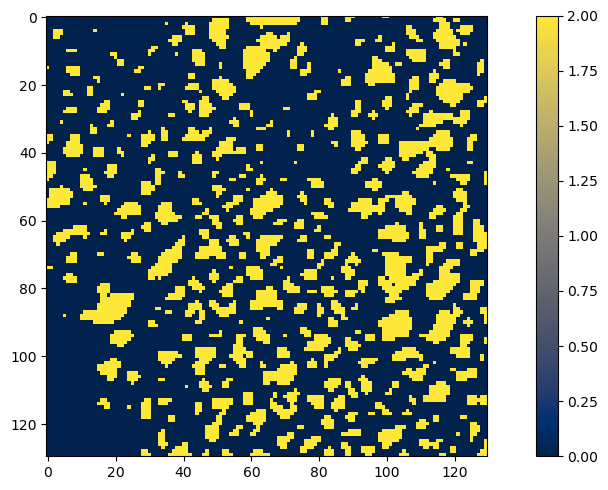

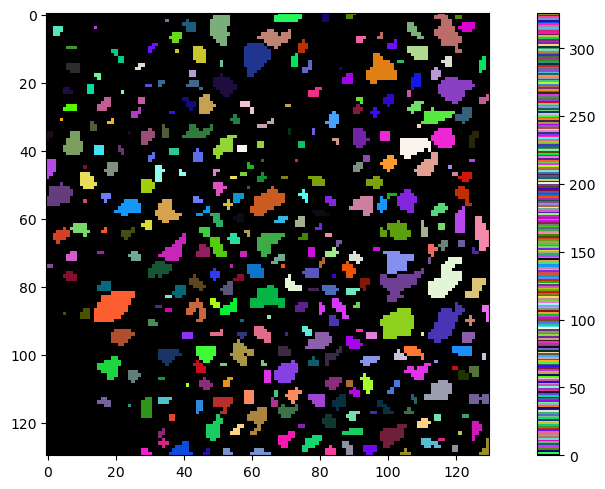

In [708]:
print('Number of crowns:', num_crown)
plotImage(image)
plotImage(relabel, 'random')

In [145]:
# Old code
'''
# Find connected components in the raster data
num_labels, labels = cv2.connectedComponents(det_filled)

# 1. Distance Transformation
# Calculate euclidean distance of every pixel from the crown edge 
eucliDist = cv2.DIST_L2
distTransform = cv2.distanceTransform(det, distanceType=eucliDist, maskSize=3, dstType=cv2.CV_8U)

# 2. Locate Instance Center (i.e. Tree crown center with the highest euclidean distance from the crown edge)
# Slide a maximum filter across the distance transform image
smallestCrownDiameterToBeSeparated = 4 # in m
spatialRes = 0.5 # in m
winsize = round(smallestCrownDiameterToBeSeparated/spatialRes) # Depends on the smallest tree in the image
winshape = cv2.MORPH_RECT
kernel = cv2.getStructuringElement(winshape, (winsize,winsize))
dilation = cv2.dilate(distTransform, kernel) #erode;dilate = min;max filter

# If a pixel has the same euclidean distance in both dilation and distTransform image, it is assigned as the instance center
binary = (distTransform == dilation).astype(np.uint8)
instanceCenter = binary * det # avoid classifying pixels = 0 as instance center
instanceCenter = (instanceCenter > 0).astype(np.uint8)

# 3. Re-lables the instance center
num_relabels, relabels = cv2.connectedComponents(instanceCenter, connectivity=8)
'''